In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

import Functions

In [14]:
df_stats = pd.read_csv('/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/TimeSeries_Coherencia.csv', index_col='Code')
df_stats['Date'] = pd.to_datetime(df_stats['Date'])
display(df_stats.index)

Index([1841224, 2081887, 1697689, 1698168, 1896343, 1889482, 1889479, 1576641,
       1697690, 1824038,
       ...
       2278835, 1841223, 1841223, 1698168, 1698168, 1896343, 1896343, 1697689,
       2294423, 1697691],
      dtype='int64', name='Code', length=3132)

In [15]:
df_stats.drop(df_stats[df_stats['mean'] == 0].index,inplace=True)
date_S1 = list(pd.unique(pd.to_datetime(df_stats['Date'])))
print(df_stats)

           Date_Band      mean       std       Date Band       Name       Type
Code                                                                          
1841224  20170104_VH  0.846021  0.060364 2017-01-04   VH     DB_A_C   Potatoes
2081887  20170104_VV  0.871518  0.039698 2017-01-04   VV  SB10_MA_C       Corn
1697689  20170104_VV  0.632827  0.077296 2017-01-04   VV   SB7_ER_C  Grassland
1698168  20170104_VV  0.798322  0.108719 2017-01-04   VV    TK_MA_C       Corn
1896343  20170104_VH  0.747334  0.065918 2017-01-04   VH   KL_MA2-C       Corn
...              ...       ...       ...        ...  ...        ...        ...
1698168  20171224_VH  0.743293  0.228359 2017-12-24   VH    TK_MA_C       Corn
1698168  20171224_VV  0.821677  0.218609 2017-12-24   VV    TK_MA_C       Corn
1896343  20171224_VV  0.832622  0.128851 2017-12-24   VV   KL_MA2-C       Corn
1896343  20171224_VH  0.666194  0.084859 2017-12-24   VH   KL_MA2-C       Corn
1697689  20171224_VH  0.892655  0.041816 2017-12-24 

In [16]:
df_height = pd.read_csv(r'/home/frank/Desktop/f.chiapperino_local/VALENCIA/SCUOLA/App/Documents/csv/Averaged_crop_height.csv', header=0)
df_height = df_height.set_index(df_height['Code'])
df_height = df_height.drop(columns=['Code'])

date_height = list(pd.to_datetime(df_height.columns))
print(date_height)

[Timestamp('2017-05-18 00:00:00'), Timestamp('2017-05-23 00:00:00'), Timestamp('2017-05-30 00:00:00'), Timestamp('2017-06-08 00:00:00'), Timestamp('2017-06-15 00:00:00'), Timestamp('2017-06-21 00:00:00'), Timestamp('2017-06-27 00:00:00'), Timestamp('2017-07-03 00:00:00'), Timestamp('2017-07-06 00:00:00'), Timestamp('2017-07-13 00:00:00'), Timestamp('2017-07-17 00:00:00'), Timestamp('2017-07-27 00:00:00'), Timestamp('2017-08-02 00:00:00'), Timestamp('2017-08-11 00:00:00'), Timestamp('2017-08-17 00:00:00'), Timestamp('2017-08-23 00:00:00'), Timestamp('2017-09-01 00:00:00'), Timestamp('2017-09-07 00:00:00'), Timestamp('2017-09-15 00:00:00')]


Create dataframe for merging

In [20]:
df_date_height = pd.DataFrame({'original_date': date_height}).sort_values('original_date')
df_date_S1 = pd.DataFrame({'ref_date': date_S1}).sort_values('ref_date')

new_date_height = pd.merge_asof(df_date_height, df_date_S1, 
                                left_on='original_date',
                                right_on='ref_date', direction='backward')

#ref_date is the one we need
display(new_date_height)

,original_date,ref_date
0,2017-05-18,2017-05-16
1,2017-05-23,2017-05-22
2,2017-05-30,2017-05-28
3,2017-06-08,2017-06-03
4,2017-06-15,2017-06-15
5,2017-06-21,2017-06-15
6,2017-06-27,2017-06-27
7,2017-07-03,2017-07-03
8,2017-07-06,2017-07-03
9,2017-07-13,2017-07-09


In [18]:
df_height.columns = new_date_height['ref_date']
display(df_height)

ref_date,2017-05-16,2017-05-22,2017-05-28,2017-06-03,2017-06-15,2017-06-15,2017-06-27,2017-07-03,2017-07-03,2017-07-09,2017-07-15,2017-07-27,2017-07-27,2017-08-08,2017-08-14,2017-08-20,2017-09-01,2017-09-07,2017-09-13
Code,,,,,,,,,,,,,,,,,,,
1545384.0,NaN,NaN,NaN,NaN,NaN,59.5,67.5,84.0,NaN,83.50,85.00,87.5,71.0,75.00,60.00,52.50,NaN,53.50,25.0
1553694.0,NaN,NaN,NaN,NaN,NaN,53.0,56.5,57.5,NaN,75.50,75.00,71.5,73.5,66.00,82.50,77.50,NaN,79.00,NaN
1576641.0,NaN,NaN,NaN,NaN,90.0,NaN,NaN,NaN,77.0,NaN,90.00,NaN,10.0,NaN,NaN,NaN,15.0,NaN,NaN
1601502.0,NaN,NaN,NaN,NaN,NaN,42.5,51.5,58.0,NaN,NaN,59.00,62.0,65.0,64.00,70.00,78.50,NaN,77.50,NaN
1631664.0,21.0,23.0,38.0,NaN,9.0,14.0,20.0,20.5,NaN,31.00,37.75,NaN,24.0,28.25,17.00,23.00,NaN,23.75,20.0
1697689.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,15.00,NaN,22.0,NaN,20.00,NaN,32.5,NaN,NaN
1697690.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.00,18.00,NaN,30.0,NaN,25.00,NaN,35.0,NaN,NaN
1697691.0,NaN,NaN,NaN,NaN,NaN,NaN,58.5,NaN,NaN,40.00,45.00,NaN,45.0,NaN,55.00,NaN,30.0,NaN,NaN
1698168.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,240.00,250.00,NaN,270.0,NaN,NaN,NaN,NaN,NaN,NaN


Preparing the dataframes for the regression

In [26]:
# Filtra i dati per la parcella 1553694
df_growth_beets = df_height.loc[1553694].dropna()
df_S1_beets = df_stats.loc[1553694].dropna()
df_S1_beets_VV = df_S1_beets[df_S1_beets['Band'] == 'VV']


df_growth_beets.index = pd.to_datetime(df_growth_beets.index)
df_growth_beets = df_growth_beets.groupby(level=0).mean()

df_S1_beets_VV.set_index(df_S1_beets_VV['Date'], inplace=True)

df_regression = pd.merge(df_growth_beets, df_S1_beets_VV['mean'], 
                         left_index=True, right_index=True, how='inner')


display(df_growth_beets)
df_regression[1553694.0] = df_regression[1553694.0].diff()

df_regression['mean'] = df_regression['mean'].diff()
#display(df_S1_beets_VV['mean'])


#print(df_S1_beets['Date'])


#print(df_S1_beets.index)

#display(df_regression)

ref_date
2017-06-15    53.0
2017-06-27    56.5
2017-07-03    57.5
2017-07-09    75.5
2017-07-15    75.0
2017-07-27    72.5
2017-08-08    66.0
2017-08-14    82.5
2017-08-20    77.5
2017-09-07    79.0
Name: 1553694.0, dtype: float64

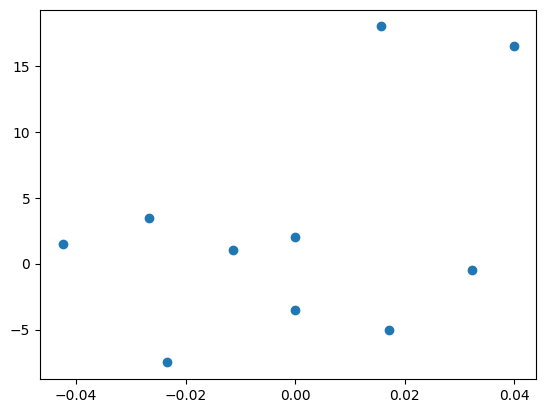

In [105]:
plt.scatter(df_regression['mean'],df_regression[1553694.0])

regressione

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.410
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     6.260
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0338
Time:                        19:03:06   Log-Likelihood:                 28.842
No. Observations:                  11   AIC:                            -53.68
Df Residuals:                       9   BIC:                            -52.89
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0822      0.043      1.905      0.0

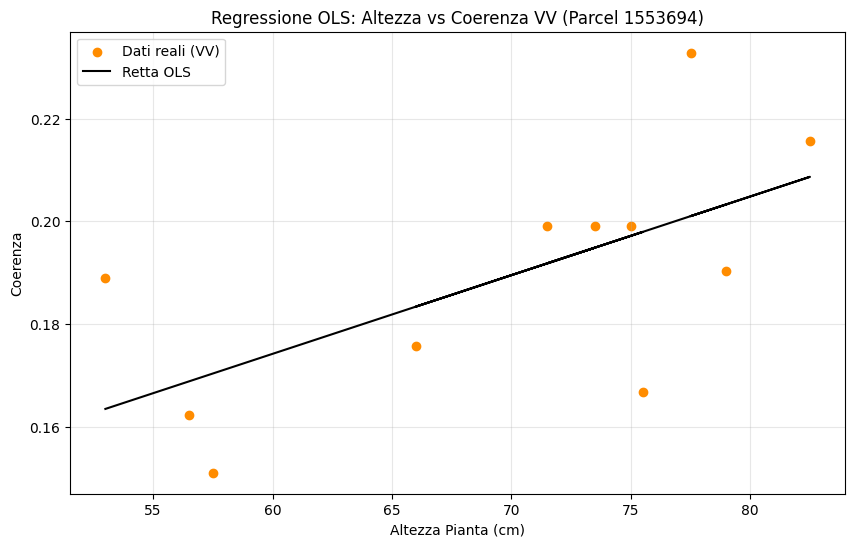

In [88]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import statsmodels.api as sm

X = list(df_regression[1553694.0])
Y = list(df_regression['mean'])

X_with_constant = sm.add_constant(X)

# Fit del modello OLS
model_ols = sm.OLS(Y, X_with_constant).fit()

# Visualizzazione dei risultati completi
print(model_ols.summary())

# Plot della retta di regressione
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='darkorange', label='Dati reali (VV)')
plt.plot(X, model_ols.predict(X_with_constant), color='black', label='Retta OLS')
plt.title('Regressione OLS: Altezza vs Coerenza VV (Parcel 1553694)')
plt.xlabel('Altezza Pianta (cm)')
plt.ylabel('Coerenza')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
